In [1]:
import os
%pwd

'/home/mahesh/MLOps_Insurance/research'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv(
    "/home/mahesh/Downloads/data.csv",
    na_values=["NA", "?"],
    parse_dates=["policy_bind_date", "incident_date"]  # Replace with your actual column name
)


In [4]:
# missing values columns
list(df.columns[df.isnull().sum() > 0])

['collision_type',
 'authorities_contacted',
 'property_damage',
 'police_report_available']

In [5]:
# Shape of the dataset
df.shape

(1000, 39)

In [6]:
# Info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

In [7]:
# Column Summary
df.describe().T

,count,mean,min,25%,50%,75%,max,std
months_as_customer,1000.0,203.954,0.0,115.75,199.5,276.25,479.0,115.113174
age,1000.0,38.948,19.0,32.0,38.0,44.0,64.0,9.140287
policy_number,1000.0,546238.648,100804.0,335980.25,533135.0,759099.75,999435.0,257063.005276
policy_bind_date,1000,2002-02-08 04:40:47.999999872,1990-01-08 00:00:00,1995-09-19 00:00:00,2002-04-01 12:00:00,2008-04-21 12:00:00,2015-02-22 00:00:00,NaN
policy_deductable,1000.0,1136.0,500.0,500.0,1000.0,2000.0,2000.0,611.864673
policy_annual_premium,1000.0,1256.40615,433.33,1089.6075,1257.2,1415.695,2047.59,244.167395
umbrella_limit,1000.0,1101000.0,-1000000.0,0.0,0.0,0.0,10000000.0,2297406.598118
insured_zip,1000.0,501214.488,430104.0,448404.5,466445.5,603251.0,620962.0,71701.610941
capital-gains,1000.0,25126.1,0.0,0.0,0.0,51025.0,100500.0,27872.187708
capital-loss,1000.0,-26793.7,-111100.0,-51500.0,-23250.0,0.0,0.0,28104.096686


In [8]:
# Segregating the columns
date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, shapiro, normaltest

# === Configuration ===
SIGNIFICANCE_LEVEL = 0.05

# === Helper Functions ===
def interpret_skewness(sk):
    if sk > 1:
        return "Highly Right-Skewed"
    elif sk > 0.5:
        return "Moderately Right-Skewed"
    elif sk < -1:
        return "Highly Left-Skewed"
    elif sk < -0.5:
        return "Moderately Left-Skewed"
    else:
        return "Approximately Symmetric"

def interpret_kurtosis(ku):
    if ku > 3:
        return "Leptokurtic (Heavy Tails)"
    elif ku < 3:
        return "Platykurtic (Light Tails)"
    else:
        return "Mesokurtic (Normal Tails)"

def test_type_from_normality(normality):
    return "Parametric" if normality == "Normal" else "Non-Parametric"

def run_normality_test(series):
    clean_series = series.dropna()
    n = len(clean_series)

    if n < 8:
        return np.nan, "Too few samples", "Test Failed"

    try:
        if n <= 5000:
            stat, p = shapiro(clean_series)
            test = "Shapiro-Wilk"
        else:
            stat, p = normaltest(clean_series)
            test = "D’Agostino K²"
        normality = "Normal" if p > SIGNIFICANCE_LEVEL else "Not Normal"
    except Exception as e:
        return np.nan, str(e), "Test Failed"

    return round(p, 4), test, normality

def interpret_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    outliers = series[(series < lower_fence) | (series > upper_fence)]
    outlier_ratio = len(outliers) / len(series)

    if outlier_ratio == 0:
        return "None"
    elif outlier_ratio < 0.01:
        return "Mild"
    elif outlier_ratio < 0.05:
        return "Moderate"
    else:
        return "Severe"

# === Analysis ===
final_results = []

num_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    series = df[col]
    clean_series = series.dropna()

    if len(clean_series) < 3:
        continue

    # Descriptive statistics
    desc = {
        "Feature": col,
        "Count": series.count(),
        "Missing": series.isna().sum(),
        "Mean": round(series.mean(), 2),
        "Median": round(series.median(), 2),
        "Std Dev": round(series.std(), 2),
        "Variance": round(series.var(), 2),
        "Min": series.min(),
        "25% (Q1)": round(series.quantile(0.25), 2),
        "75% (Q3)": round(series.quantile(0.75), 2),
        "Max": series.max(),
        "Range": round(series.max() - series.min(), 2),
        "IQR": round(series.quantile(0.75) - series.quantile(0.25), 2),
    }

    # Shape statistics
    sk = skew(clean_series)
    ku = kurtosis(clean_series, fisher=False)  # Normal kurtosis = 3

    desc["Skewness"] = round(sk, 4)
    desc["Skewness Type"] = interpret_skewness(sk)
    desc["Kurtosis"] = round(ku, 4)
    desc["Tails"] = interpret_kurtosis(ku)

    # Normality test (adaptive)
    p_value, test_used, normality = run_normality_test(clean_series)
    desc["Normality Test"] = test_used
    desc["Normality p-value"] = p_value
    desc["Normality"] = normality
    desc["Recommended Test Type"] = test_type_from_normality(normality)

    # Outliers
    desc["Outliers"] = interpret_outliers(clean_series)

    final_results.append(desc)

# === Save Results ===
summary_df = pd.DataFrame(final_results)
summary_df.to_csv("../report/summary.csv", index=False)

print("✅ Summary saved to '../report/summary.csv'")
summary_df.head()


✅ Summary saved to '../report/summary.csv'


,Feature,Count,Missing,Mean,Median,Std Dev,Variance,Min,25% (Q1),75% (Q3),...,IQR,Skewness,Skewness Type,Kurtosis,Tails,Normality Test,Normality p-value,Normality,Recommended Test Type,Outliers
0,months_as_customer,1000,0,203.95,199.5,115.11,1.325104e+04,0.00,115.75,276.25,...,160.50,0.3616,Approximately Symmetric,2.5110,Platykurtic (Light Tails),Shapiro-Wilk,0.0000,Not Normal,Non-Parametric,None
1,age,1000,0,38.95,38.0,9.14,8.354000e+01,19.00,32.00,44.00,...,12.00,0.4783,Approximately Symmetric,2.7351,Platykurtic (Light Tails),Shapiro-Wilk,0.0000,Not Normal,Non-Parametric,Mild
2,policy_number,1000,0,546238.65,533135.0,257063.01,6.608139e+10,100804.00,335980.25,759099.75,...,423119.50,0.0389,Approximately Symmetric,1.8670,Platykurtic (Light Tails),Shapiro-Wilk,0.0000,Not Normal,Non-Parametric,None
3,policy_deductable,1000,0,1136.00,1000.0,611.86,3.743784e+05,500.00,500.00,2000.00,...,1500.00,0.4772,Approximately Symmetric,1.6239,Platykurtic (Light Tails),Shapiro-Wilk,0.0000,Not Normal,Non-Parametric,None
4,policy_annual_premium,1000,0,1256.41,1257.2,244.17,5.961772e+04,433.33,1089.61,1415.70,...,326.09,0.0044,Approximately Symmetric,3.0675,Leptokurtic (Heavy Tails),Shapiro-Wilk,0.9793,Normal,Parametric,Mild


### Missing Value Analysis 

In [10]:
# Calculate missing value stats
missing_info = []

for col in df.columns:
    total = len(df)
    missing = df[col].isnull().sum()
    missing_pct = (missing / total) * 100
    dtype = df[col].dtype

    if missing > 0:
        missing_info.append({
            "Feature": col,
            "Data Type": dtype,
            "Missing Count": missing,
            "Missing %": round(missing_pct, 2),
            "Total Values": total
        })

# Convert to DataFrame
missing_df = pd.DataFrame(missing_info)

# Sort by percentage of missing values
missing_df.sort_values(by="Missing %", ascending=False, inplace=True)
missing_df

,Feature,Data Type,Missing Count,Missing %,Total Values
2,property_damage,object,360,36.0,1000
3,police_report_available,object,343,34.3,1000
0,collision_type,object,178,17.8,1000
1,authorities_contacted,object,91,9.1,1000


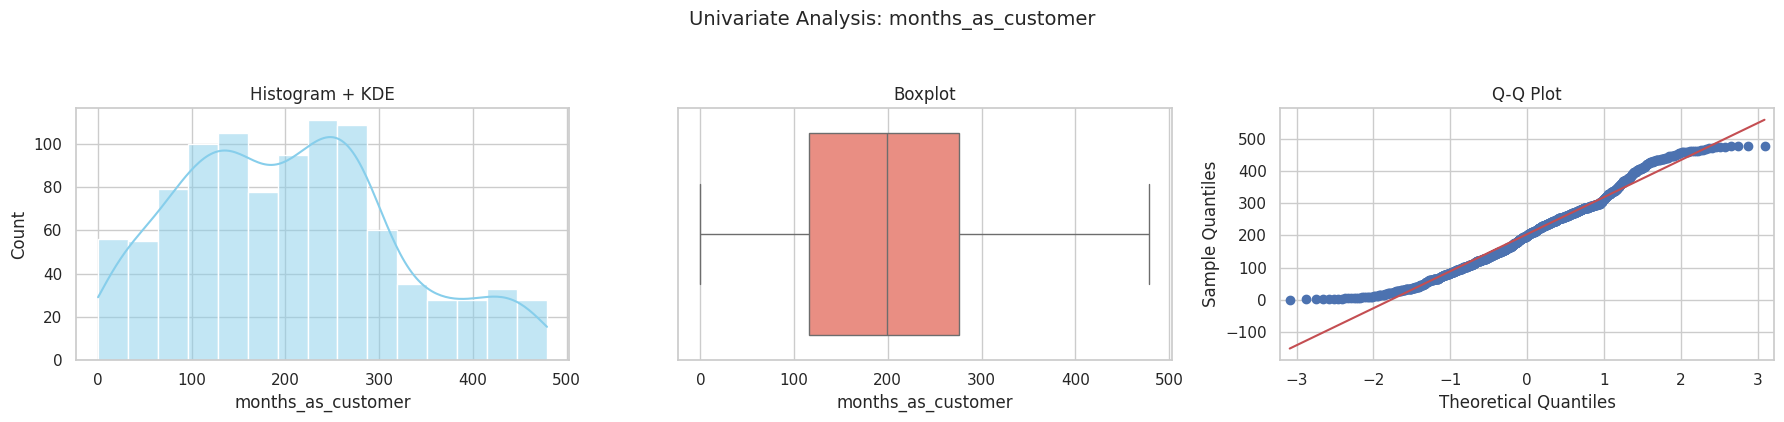

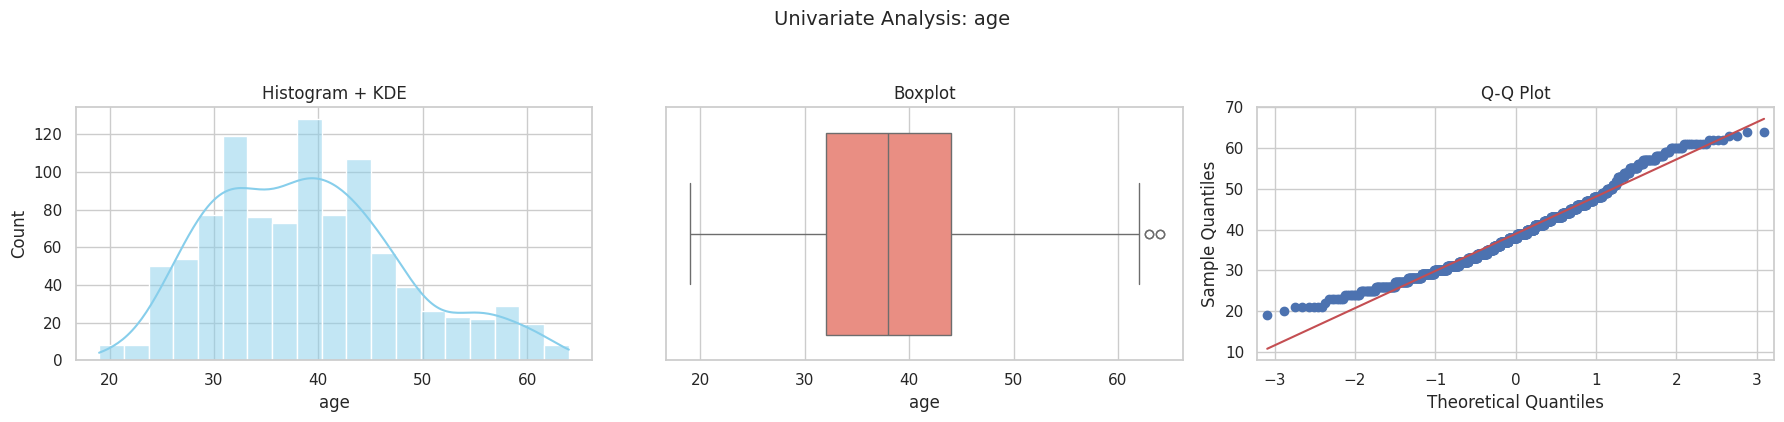

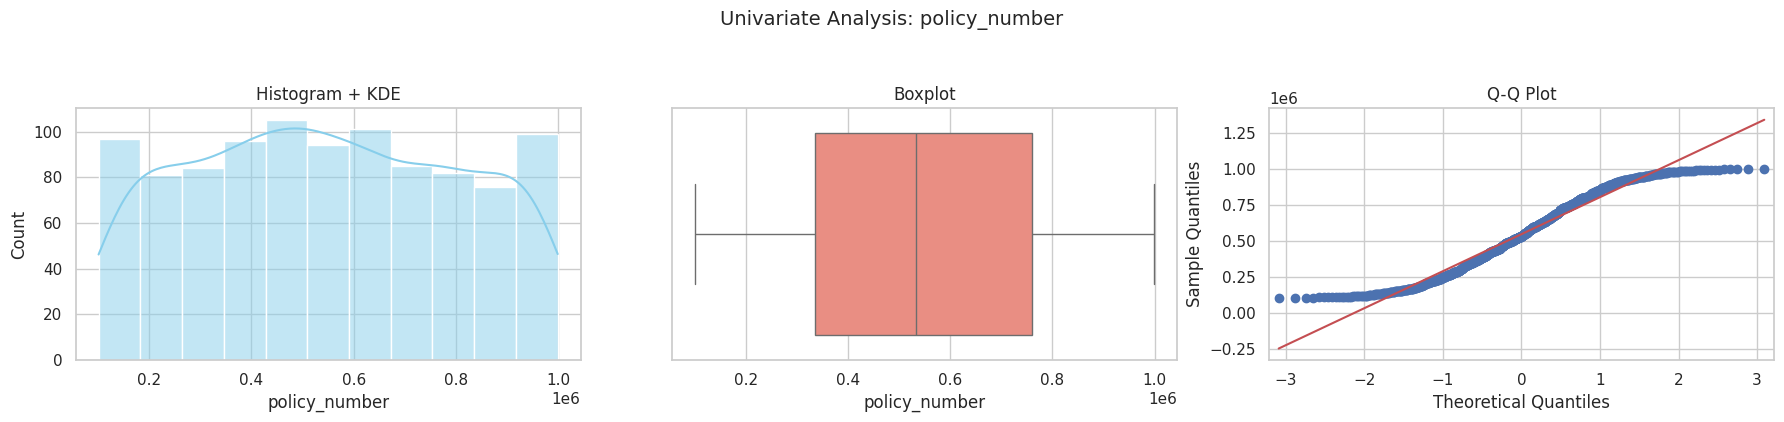

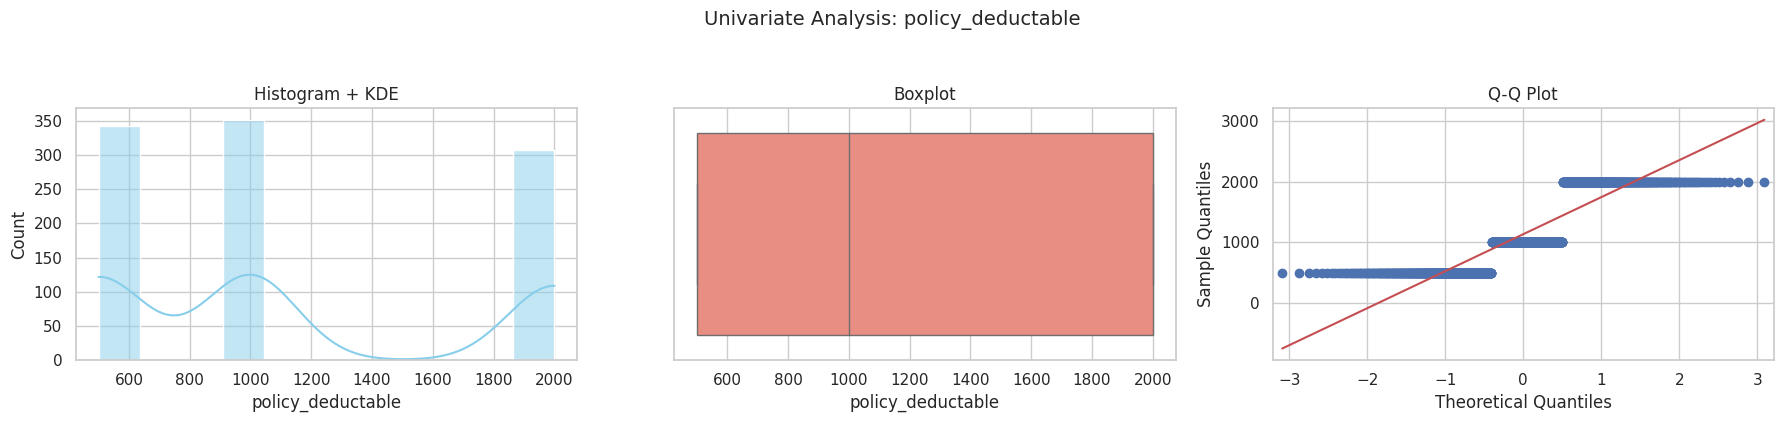

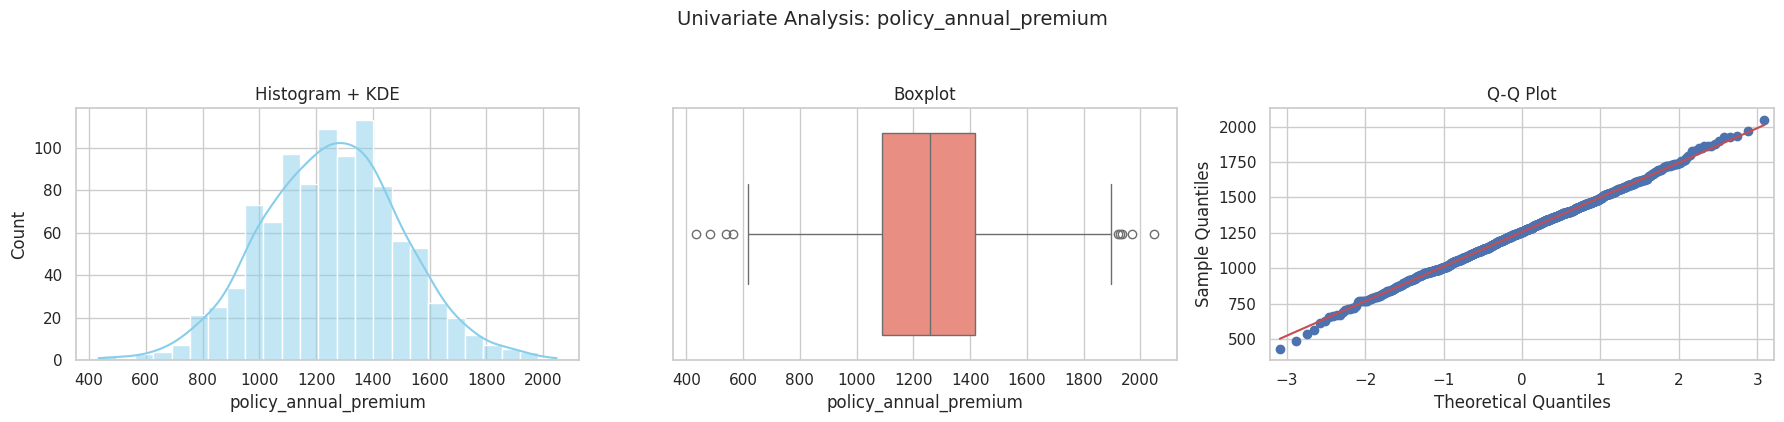

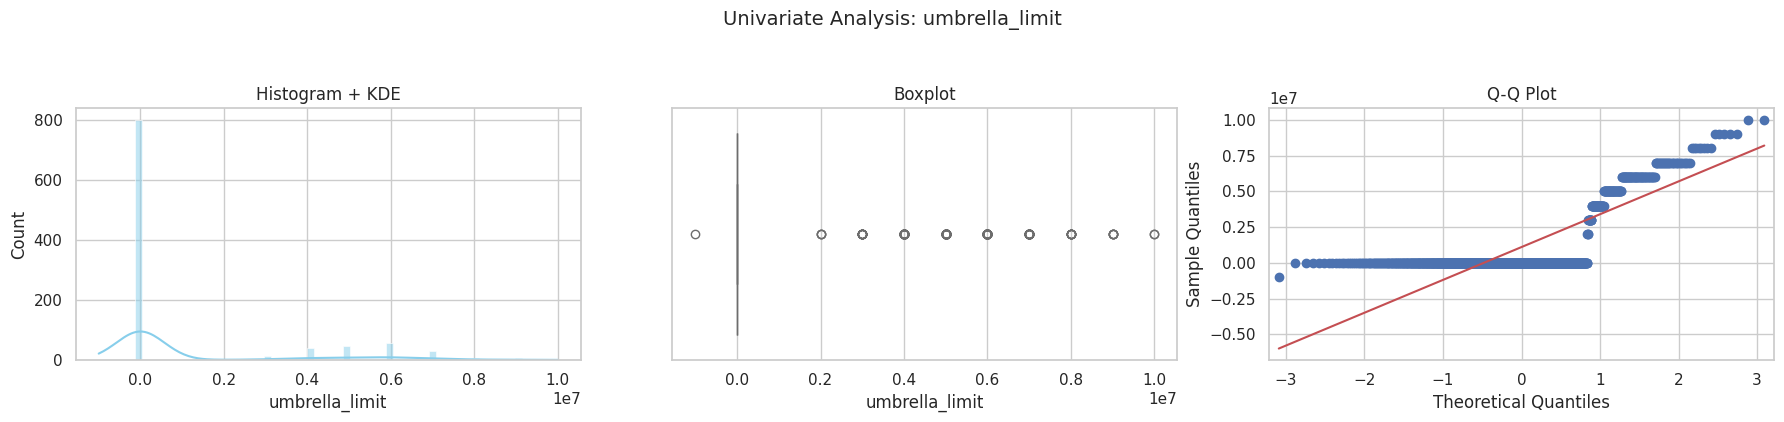

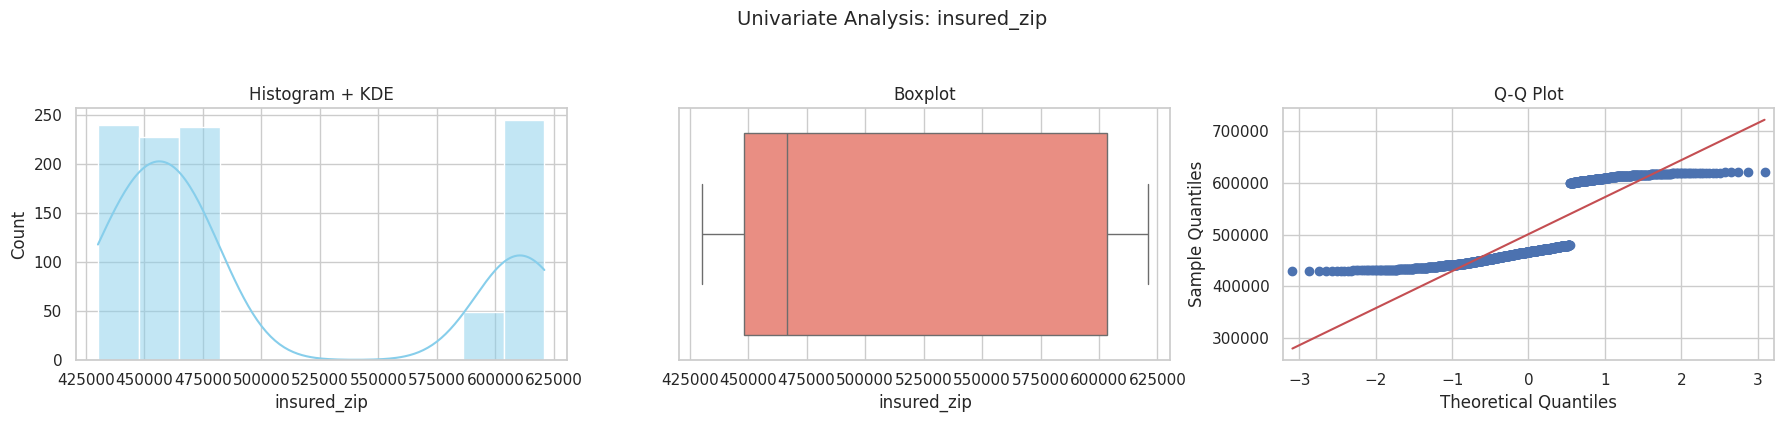

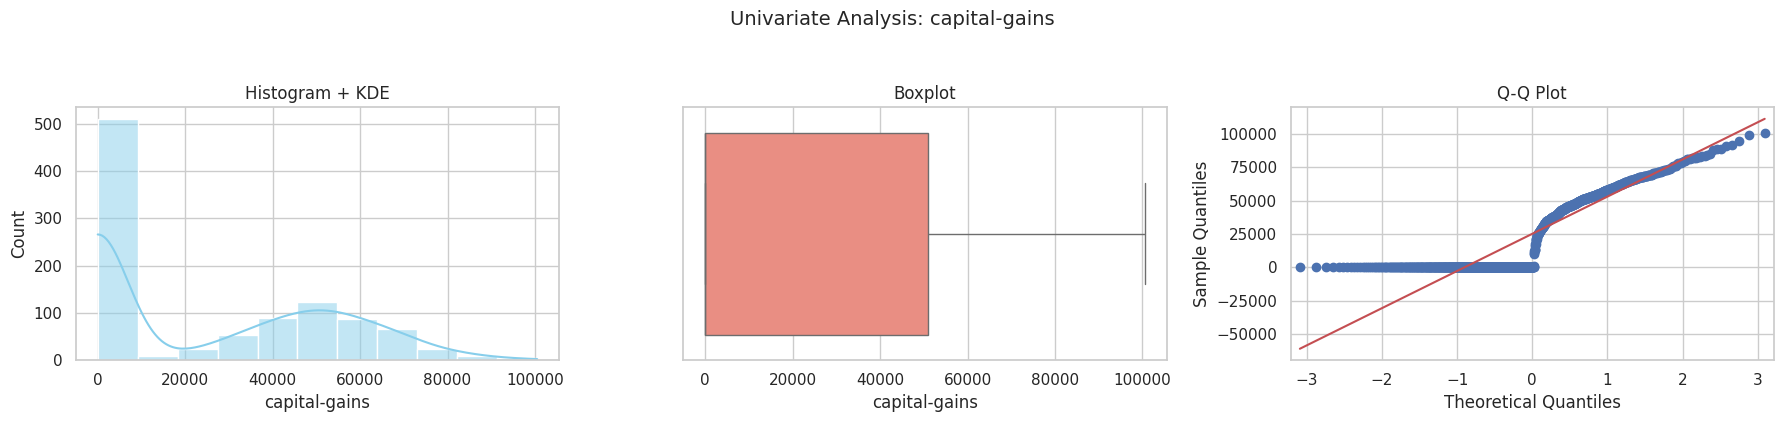

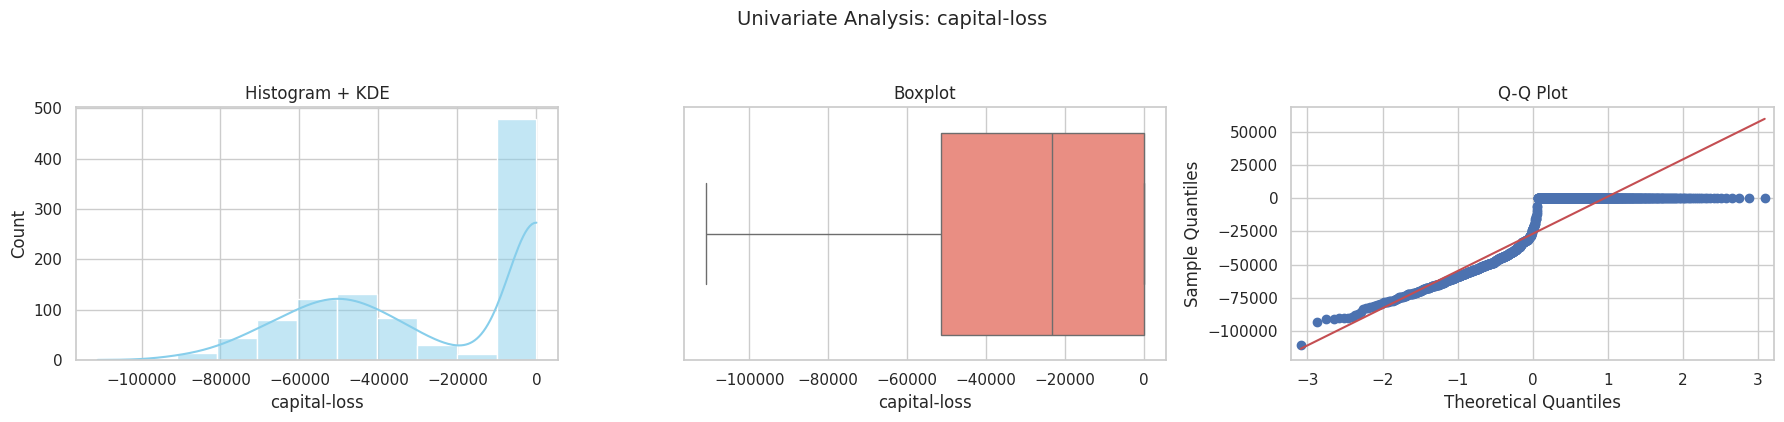

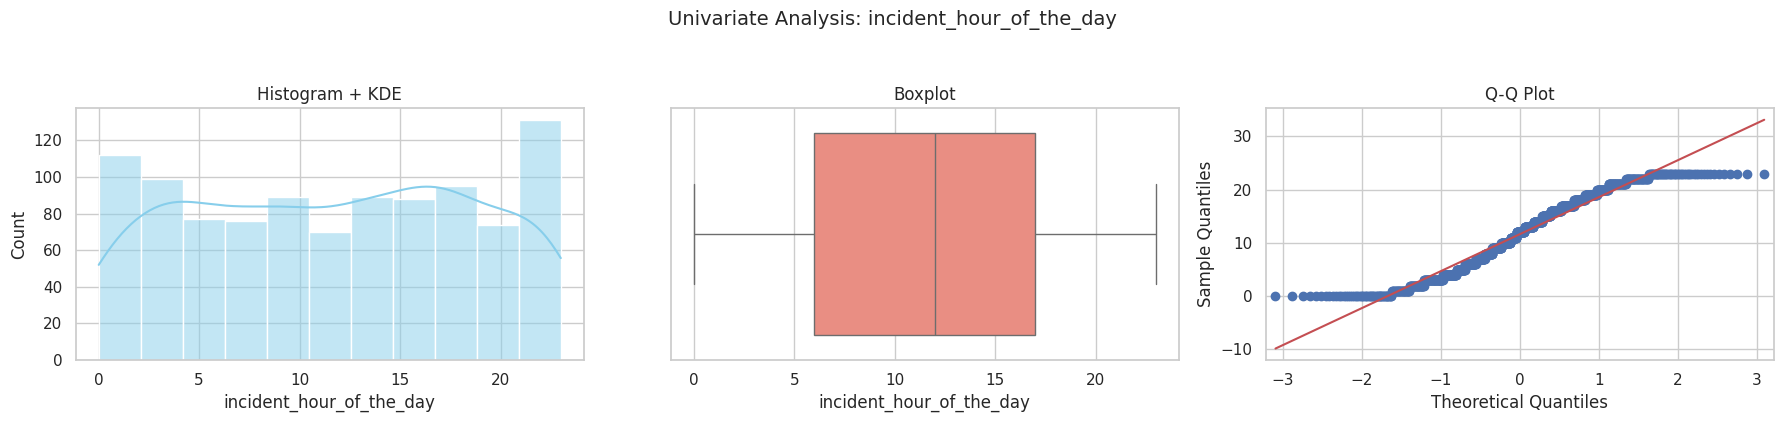

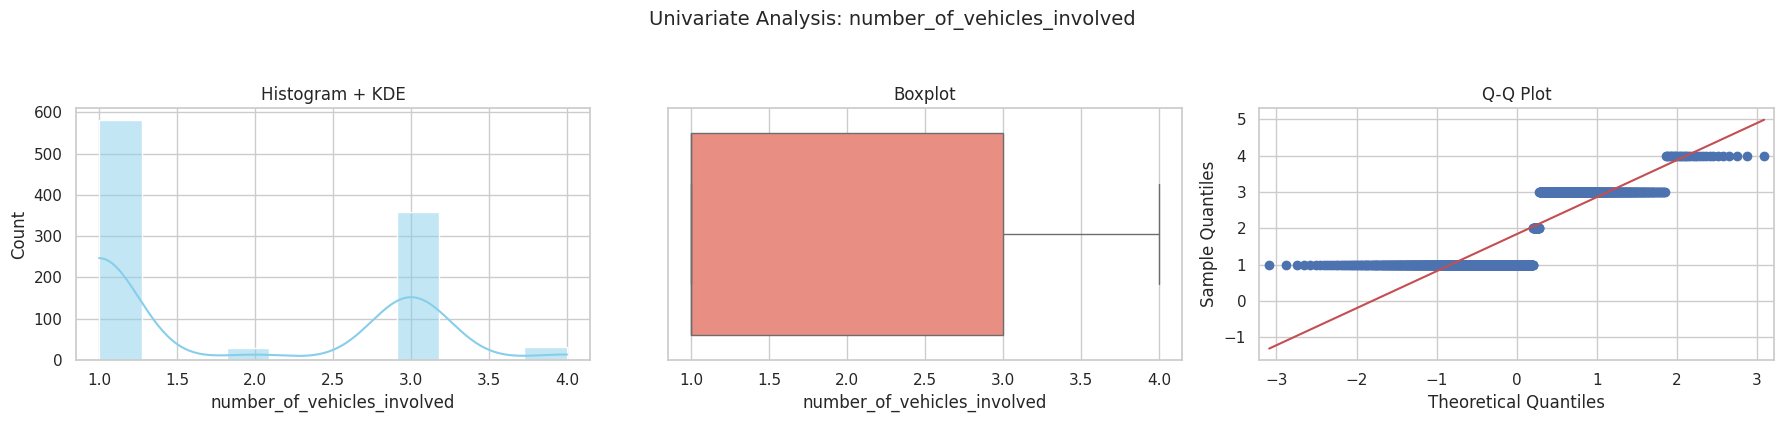

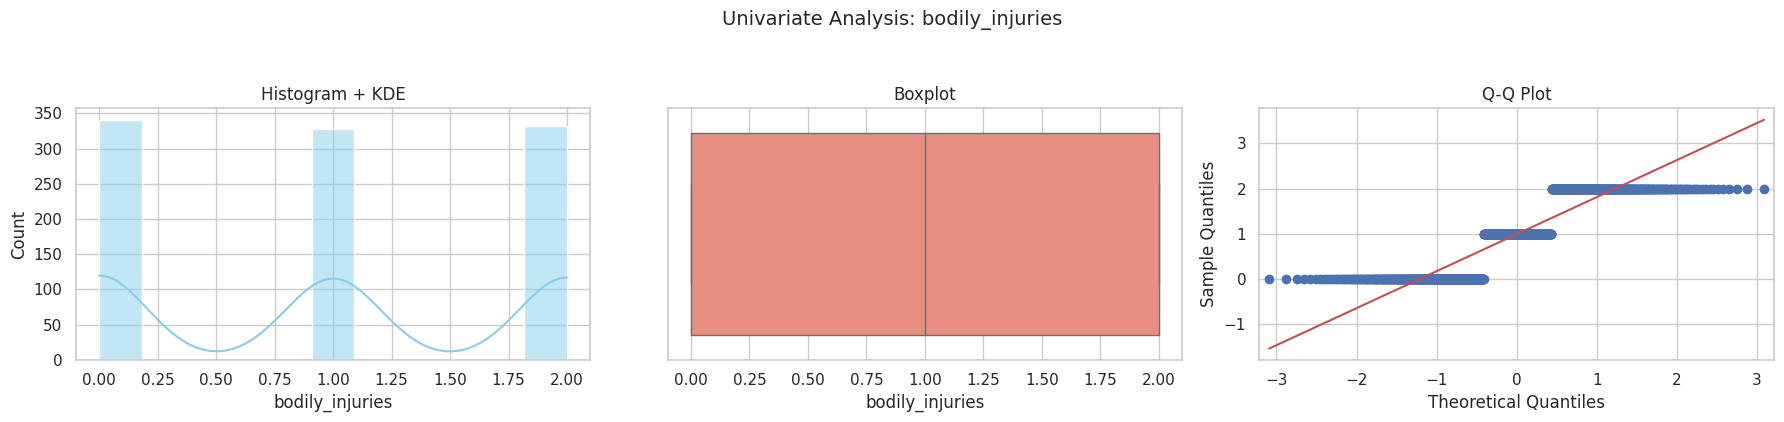

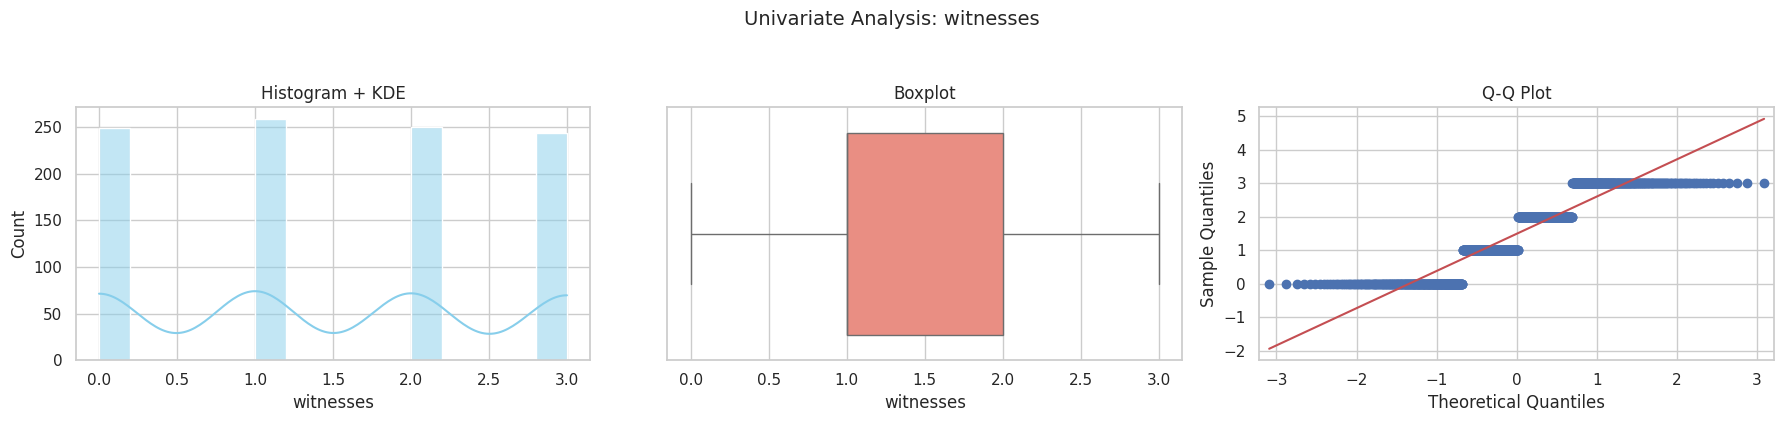

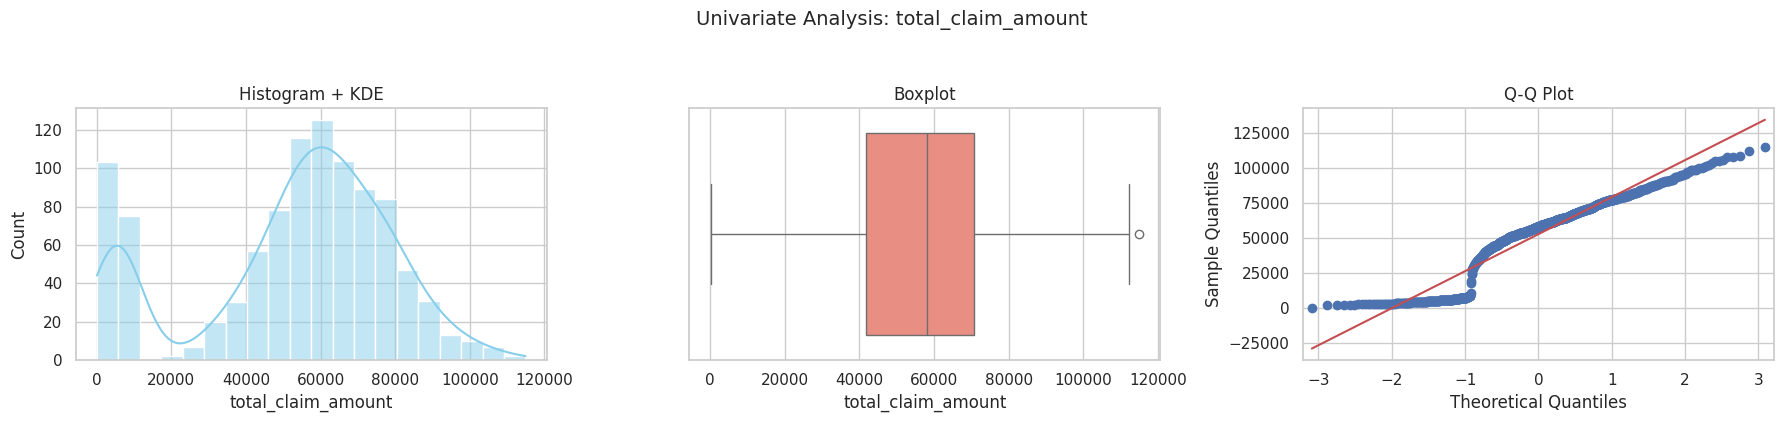

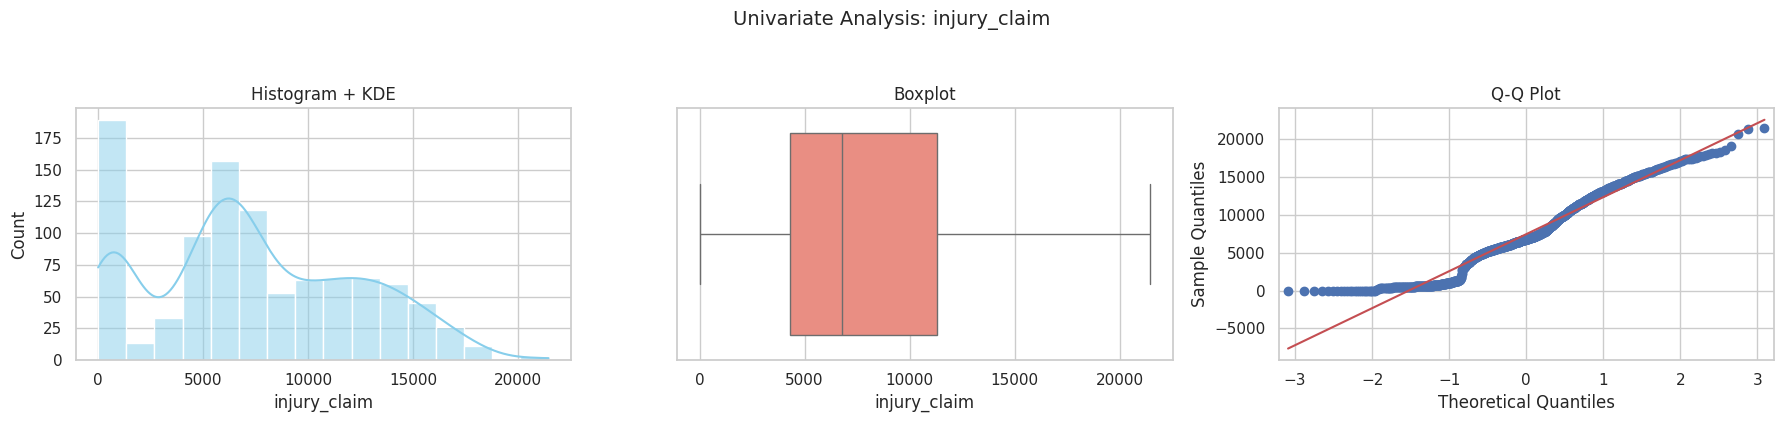

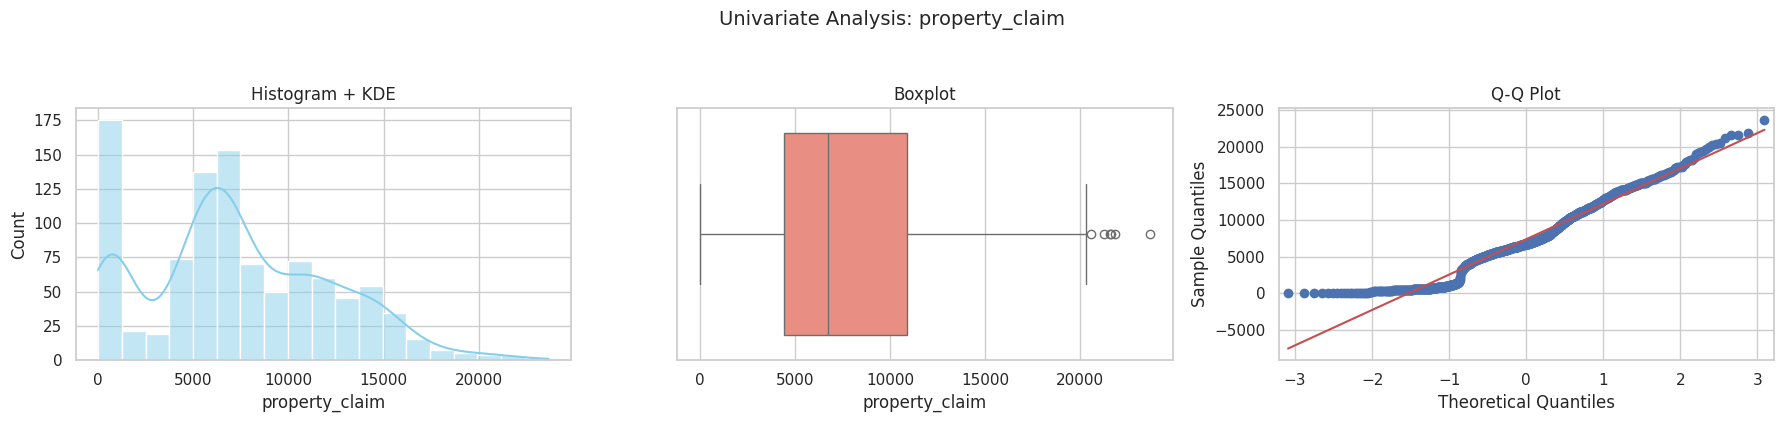

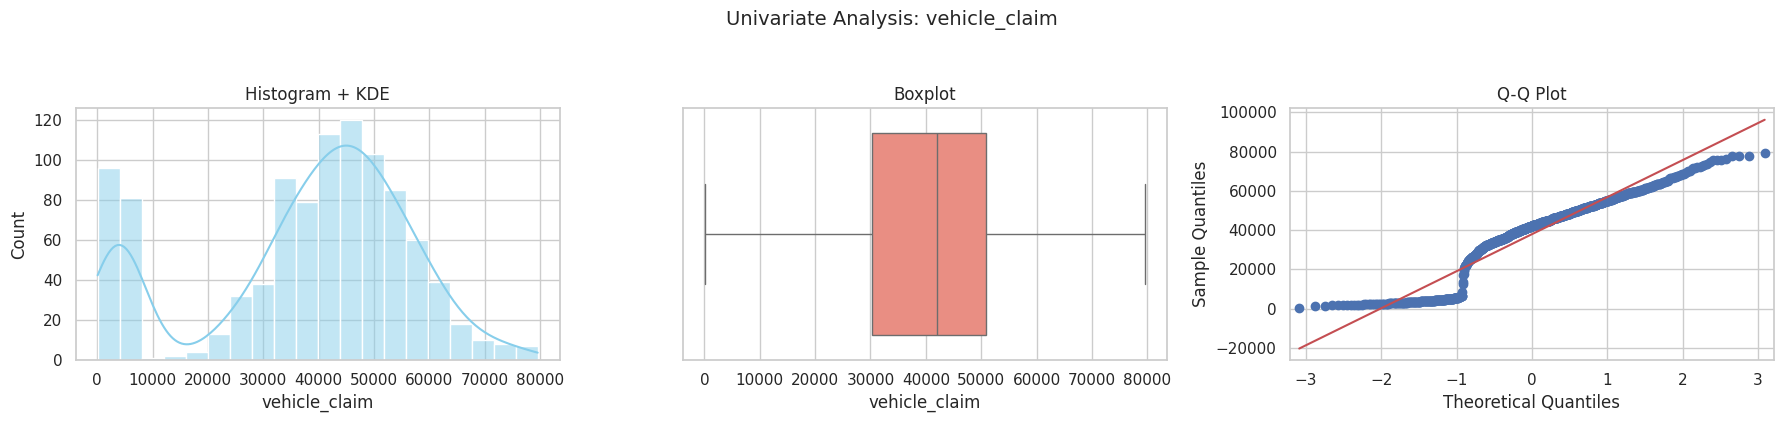

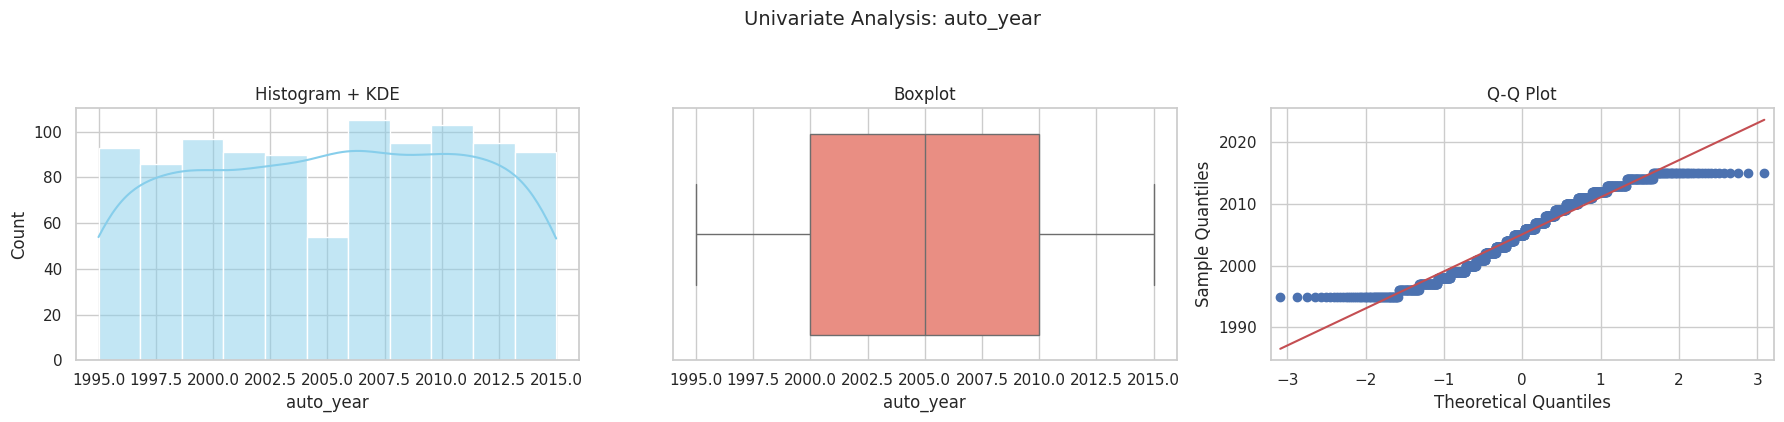

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot

# === Identify Numerical Columns ===
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# === Configure Style ===
sns.set(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})  # suppress warnings

# === Loop through each column ===
for col in num_cols:
    series = df[col].dropna()

    if len(series) < 3:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Univariate Analysis: {col}", fontsize=14, y=1.05)

    # Histogram + KDE
    sns.histplot(series, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title("Histogram + KDE")
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(x=series, ax=axes[1], color='salmon')
    axes[1].set_title("Boxplot")
    axes[1].set_xlabel(col)

    # Q-Q Plot
    qqplot(series, line='s', ax=axes[2])
    axes[2].set_title("Q-Q Plot")

    # Layout and show
    plt.tight_layout()
    plt.show()

### According to above Graphs, we can say that:
- policy_deductable, umbrella_limit, bodily_injuries, incident_hour_of_the_day, number_of_vehicles_involved, insured_zip, witnesses are the numerical columns that can able to convert into categorical columns.

In [12]:
# Define your conditions
conditions = [
    df['policy_deductable'] == 500,
    df['policy_deductable'] == 1000,
    df['policy_deductable'] == 2000
]

# Define corresponding categories
categories = ['Low', 'Medium', 'High']

# Create a new categorical column
df['policy_deductable_cat'] = np.select(conditions, categories, default='Unknown')

In [13]:
conditions = [
    df['umbrella_limit'] == 0,
    df['umbrella_limit'] == 600000,
    df['umbrella_limit'] == 1200000,
    df['umbrella_limit'] == 2000000,
    df['umbrella_limit'] == 3000000
]

categories = ['None', 'Basic', 'Standard', 'Extended', 'Premium']

df['umbrella_limit_cat'] = np.select(conditions, categories, default='Unknown')

In [14]:
conditions = [
    df['bodily_injuries'] == 0,
    df['bodily_injuries'] == 1,
    df['bodily_injuries'] == 2
]

categories = ['None', 'Minor', 'Major']

df['bodily_injuries_cat'] = np.select(conditions, categories, default='Unknown')

In [15]:
# Define conditions for time segments
conditions = [
    (df['incident_hour_of_the_day'] >= 0) & (df['incident_hour_of_the_day'] < 6),
    (df['incident_hour_of_the_day'] >= 6) & (df['incident_hour_of_the_day'] < 12),
    (df['incident_hour_of_the_day'] >= 12) & (df['incident_hour_of_the_day'] < 18),
    (df['incident_hour_of_the_day'] >= 18) & (df['incident_hour_of_the_day'] <= 23)
]

# Corresponding categories
categories = ['Early Morning', 'Morning', 'Afternoon', 'Evening']

# Apply transformation
df['incident_hour_cat'] = np.select(conditions, categories, default='Unknown')

In [16]:
conditions = [
    df['number_of_vehicles_involved'] == 1,
    df['number_of_vehicles_involved'] == 2,
    df['number_of_vehicles_involved'] >= 3
]

categories = ['Single Vehicle', 'Two Vehicles', 'Multi-Vehicle']

df['vehicles_involved_cat'] = np.select(conditions, categories, default='Unknown')


In [17]:
conditions = [
    df['witnesses'] == 0,
    df['witnesses'] == 1,
    df['witnesses'] >= 2
]

categories = ['No Witness', 'Single Witness', 'Multiple Witnesses']

df['witnesses_cat'] = np.select(conditions, categories, default='Unknown')


In [18]:
# Step 1: Ensure the column is string (if not already)
df['policy_csl'] = df['policy_csl'].astype(str)

# Step 2: Define conditions for each known CSL level
conditions = [
    df['policy_csl'] == '100/300',
    df['policy_csl'] == '250/500',
    df['policy_csl'] == '500/1000'
]

# Step 3: Define corresponding labels
labels = ['Basic', 'Standard', 'Premium']

# Step 4: Apply using np.select
df['policy_csl_cat'] = np.select(conditions, labels, default='Other')


In [19]:
columns_to_drop = [
    'insured_zip', 'policy_number', 'policy_deductable', 
    'umbrella_limit', 'bodily_injuries', 'incident_hour_of_the_day',
    'number_of_vehicles_involved', 'witnesses', 'policy_csl'
]

In [20]:
df.drop(columns=columns_to_drop, inplace=True)

In [22]:
df.to_csv("cleaned_data.csv", index=False)

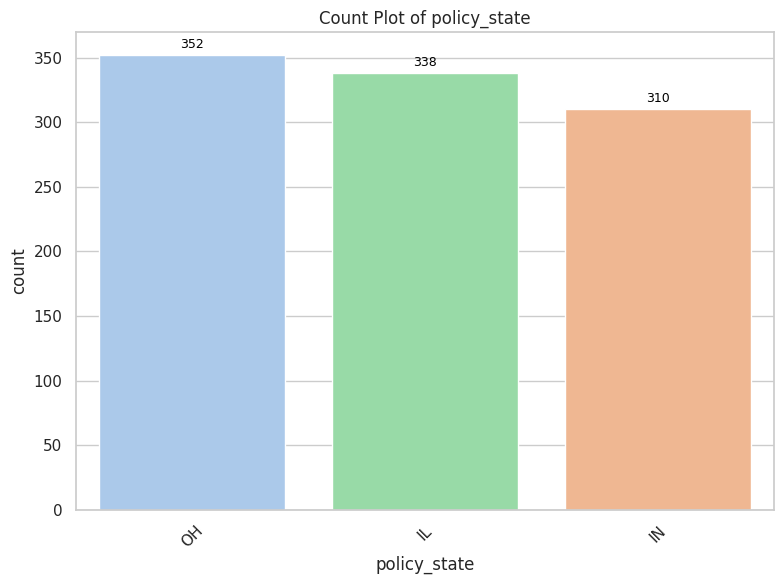

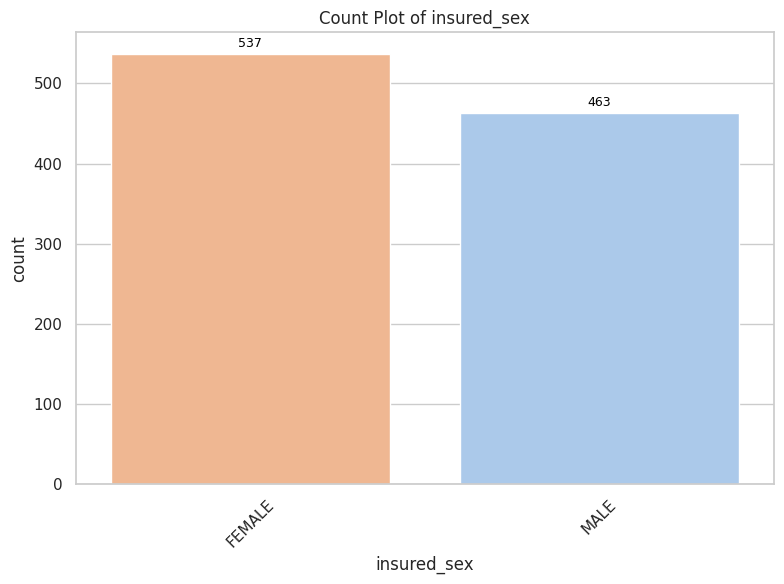

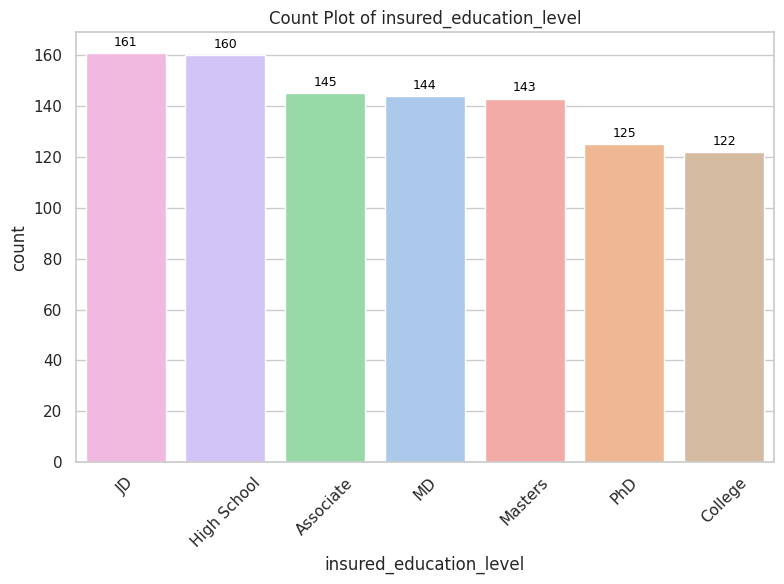

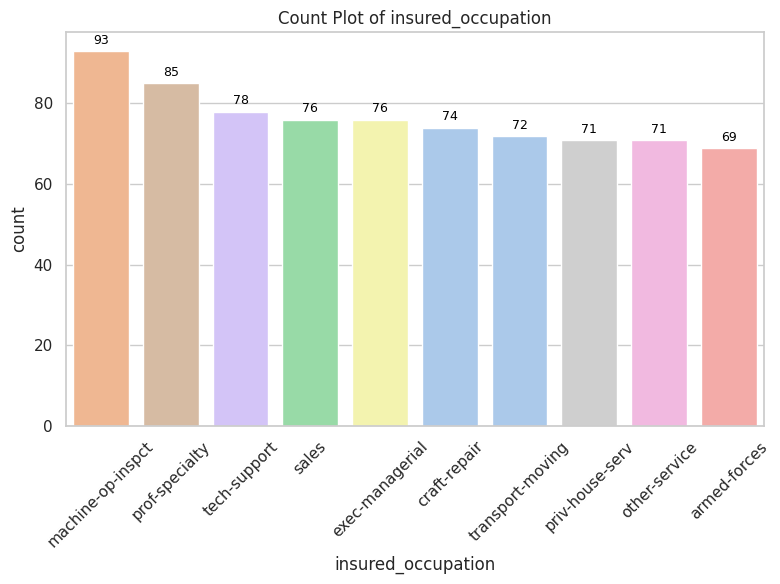

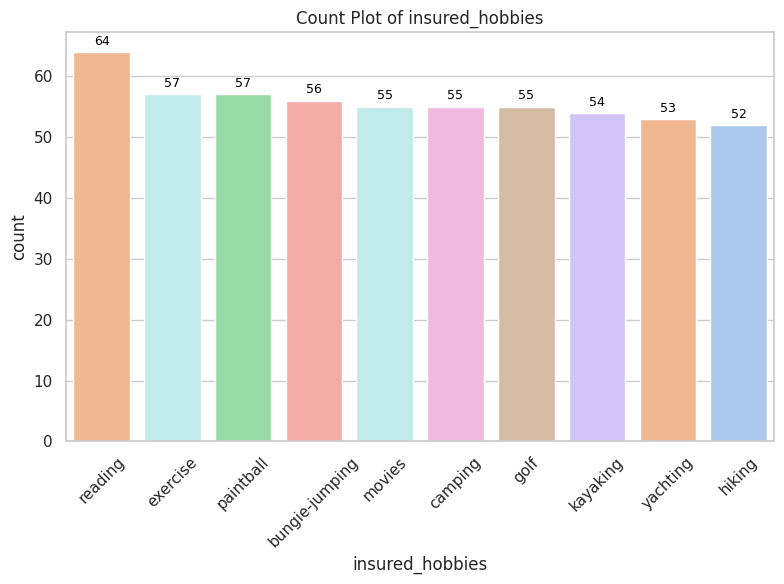

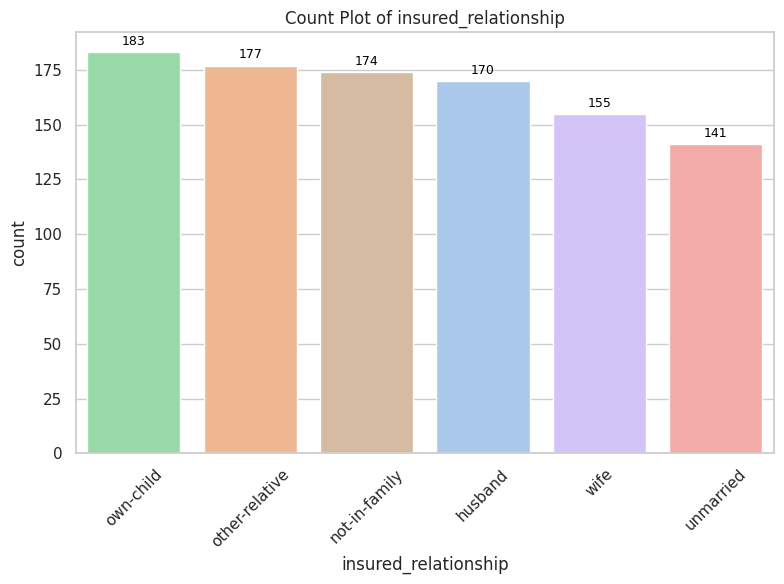

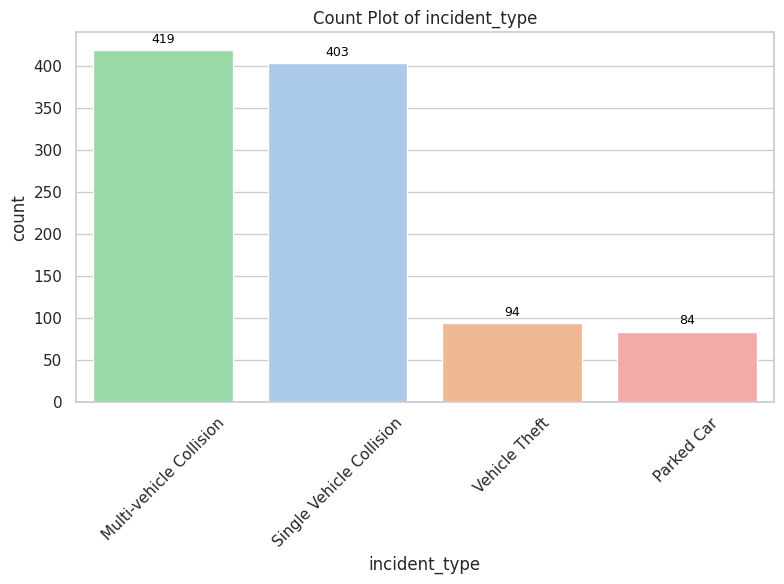

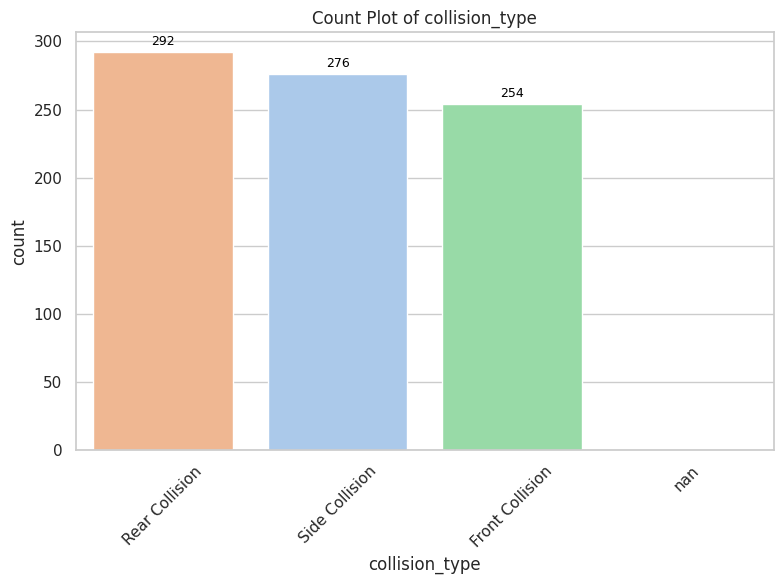

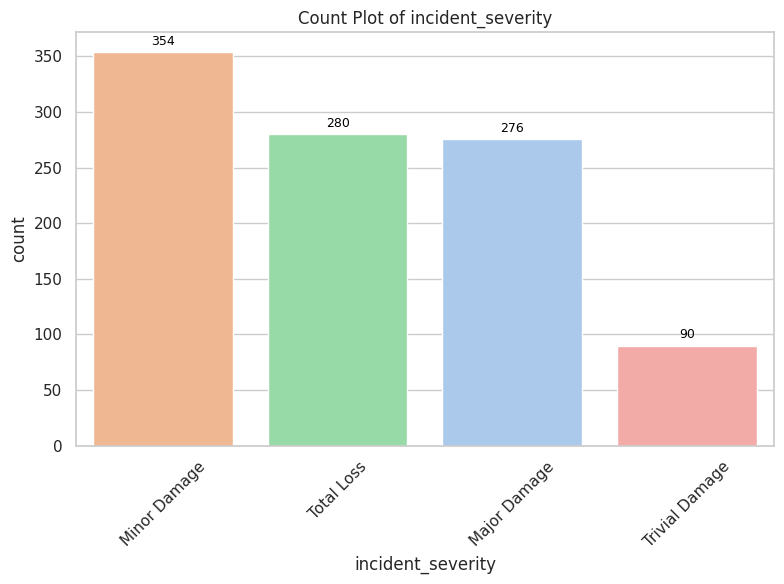

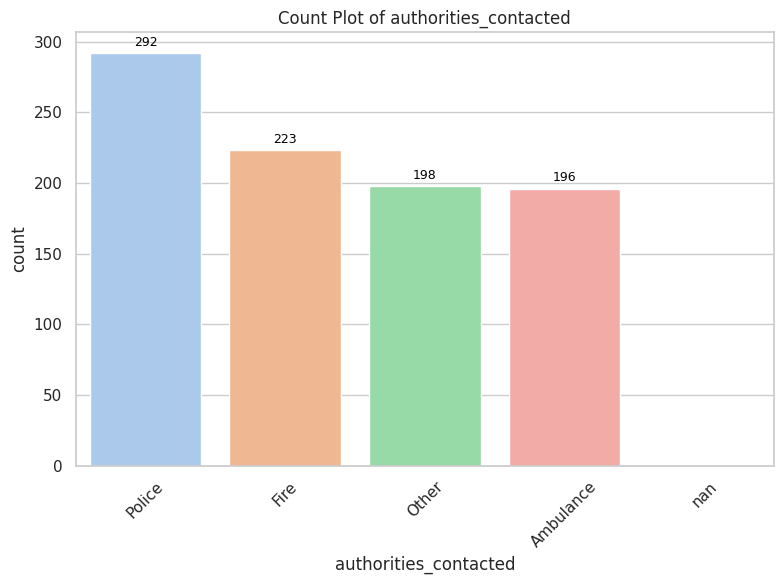

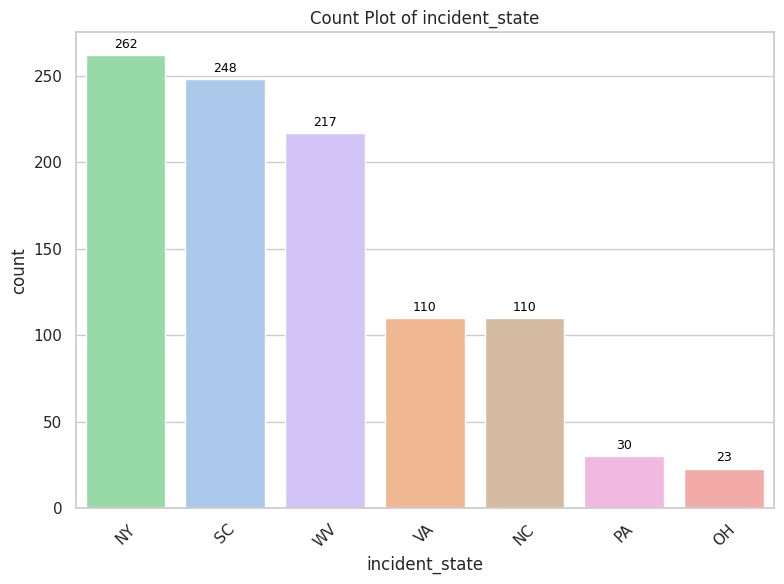

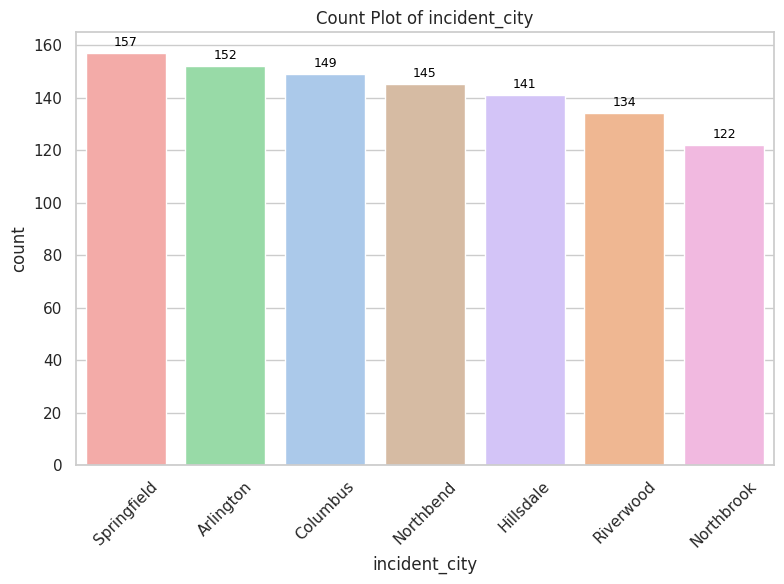

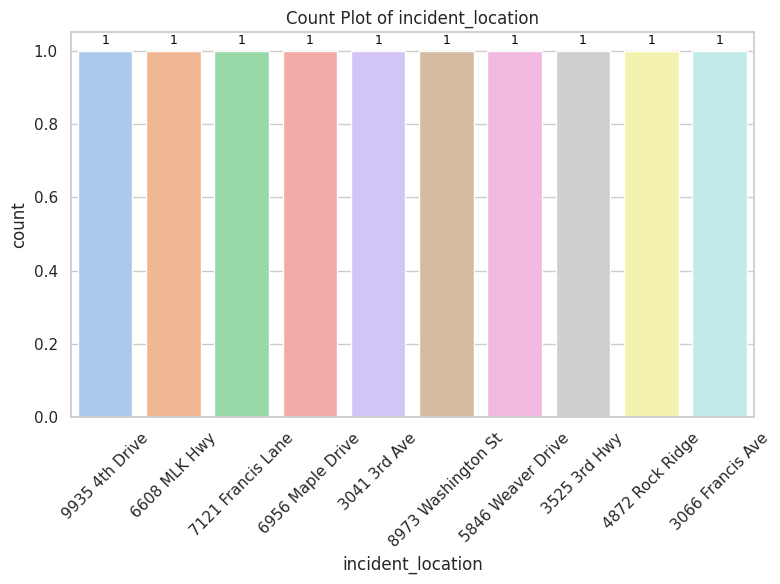

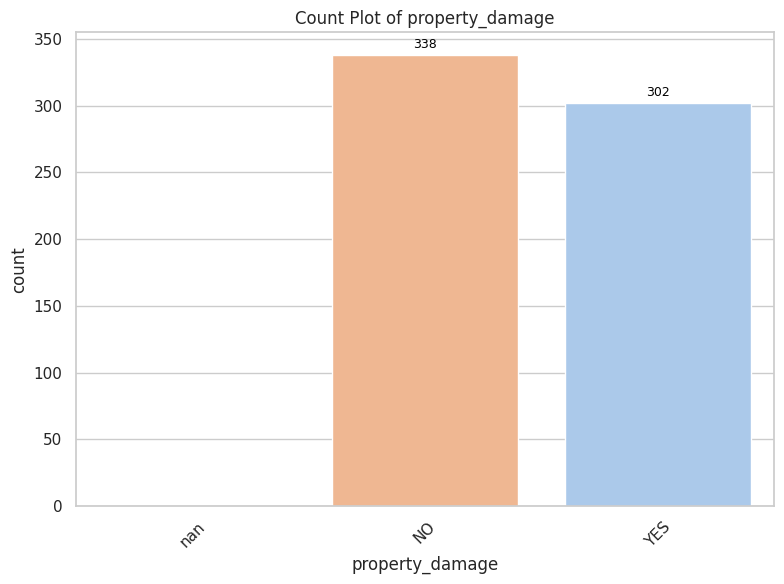

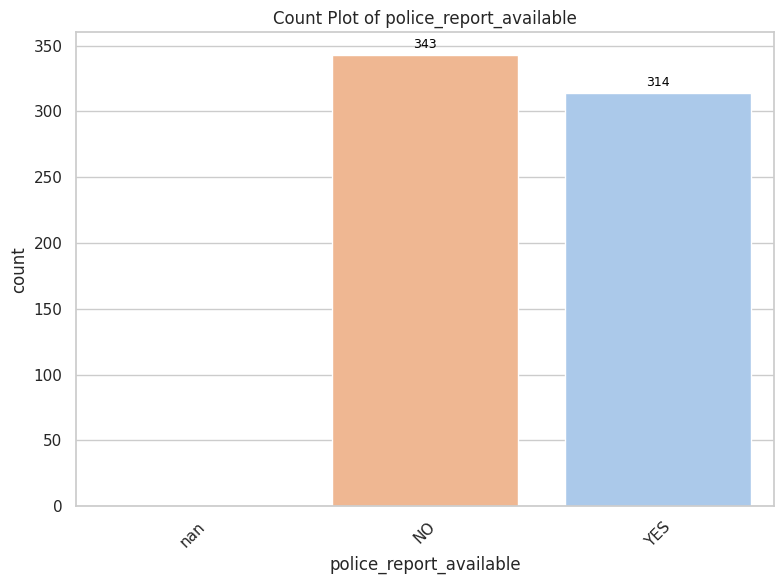

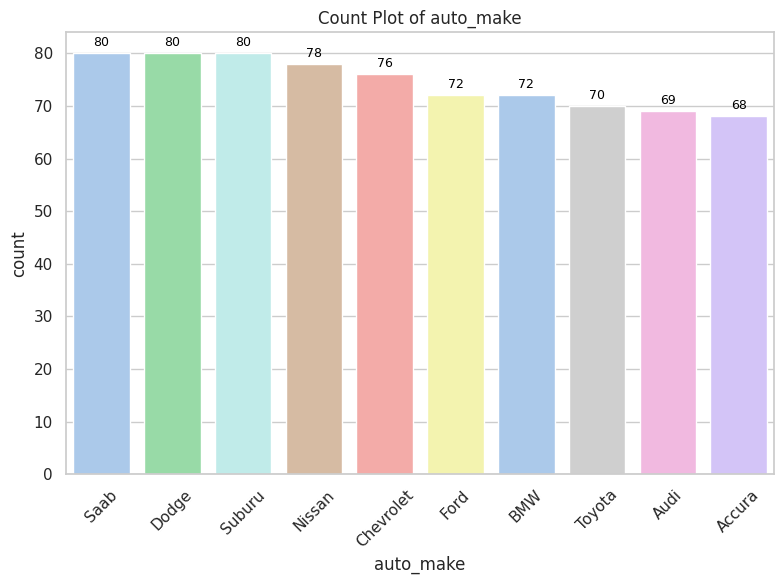

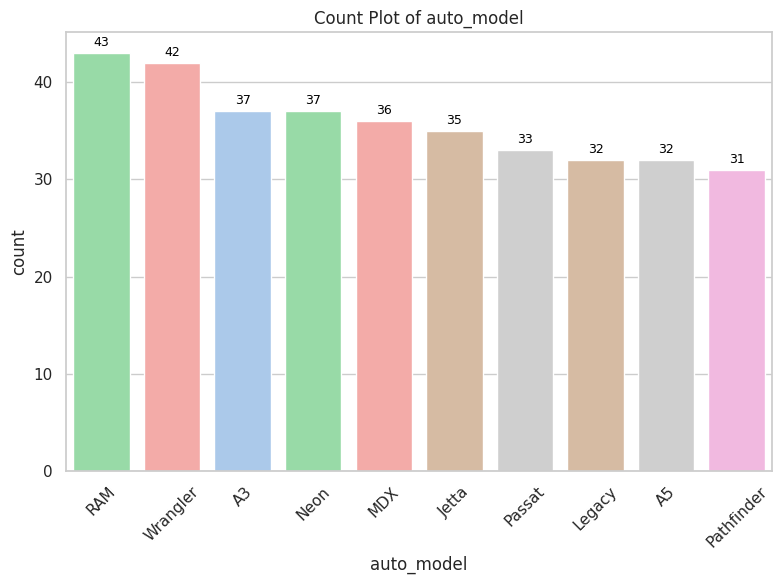

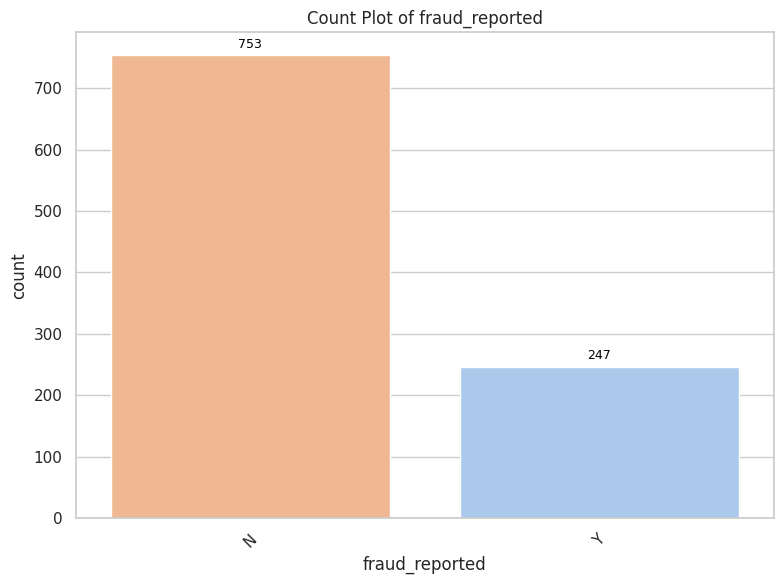

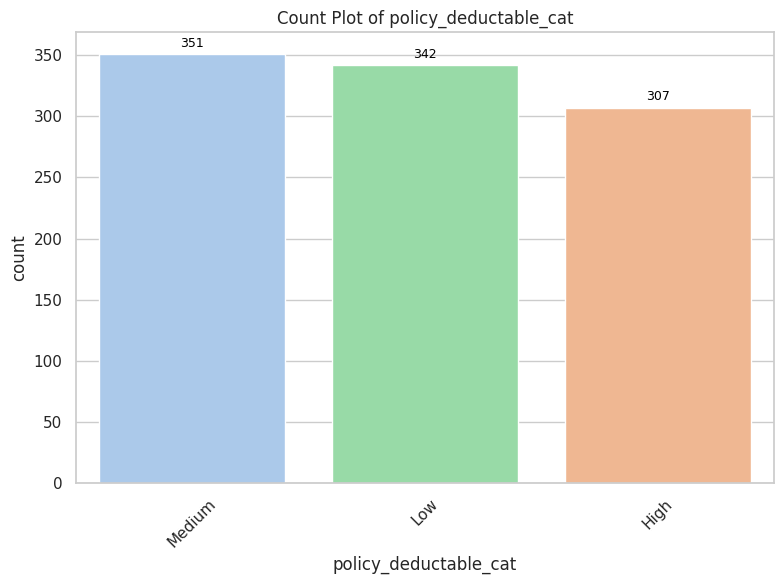

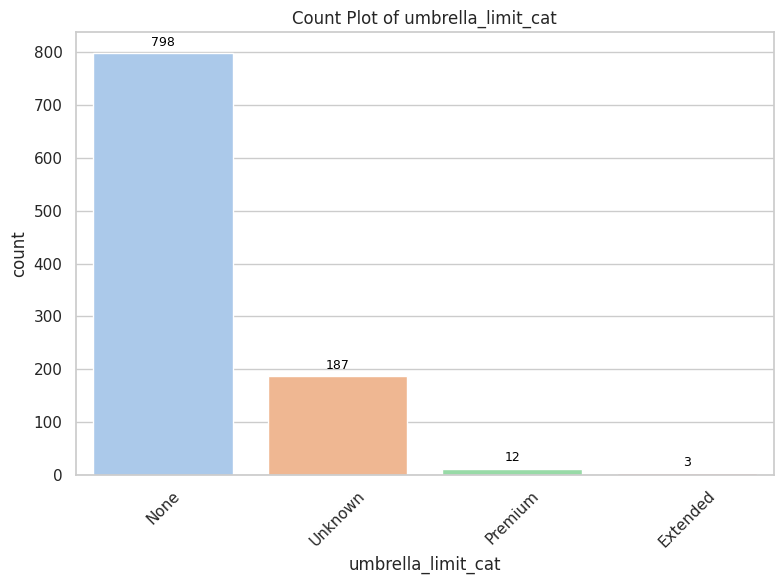

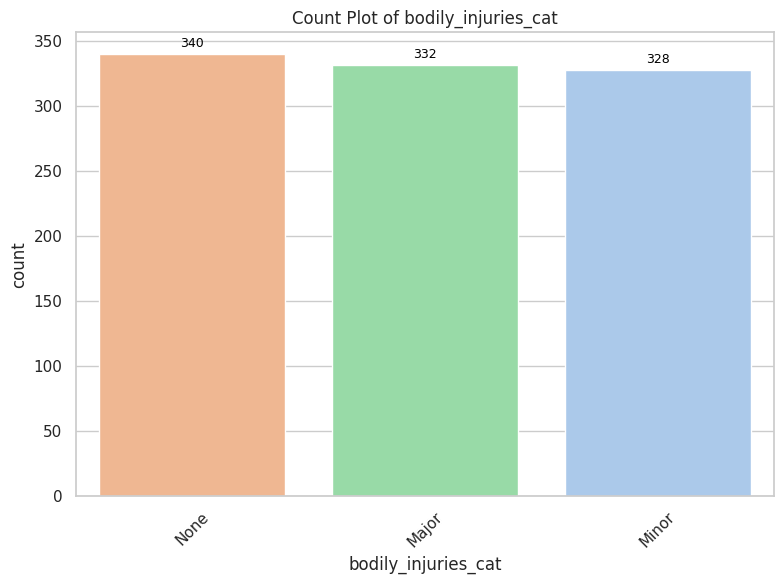

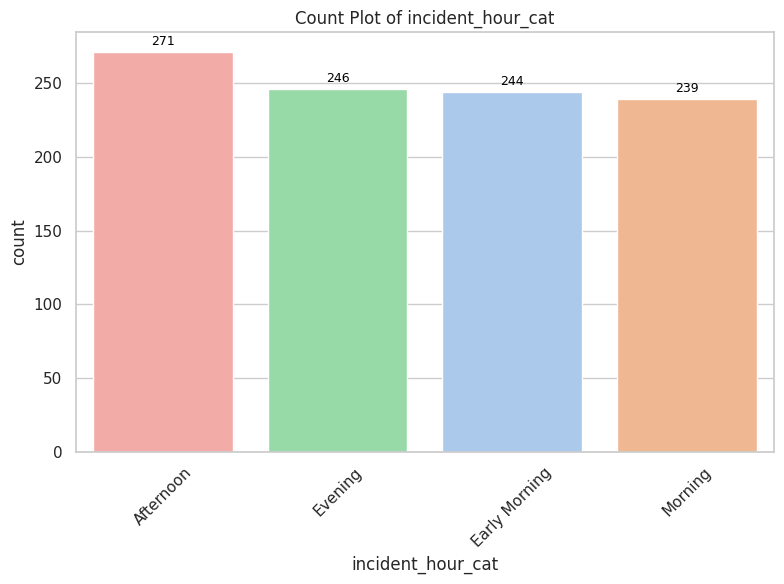

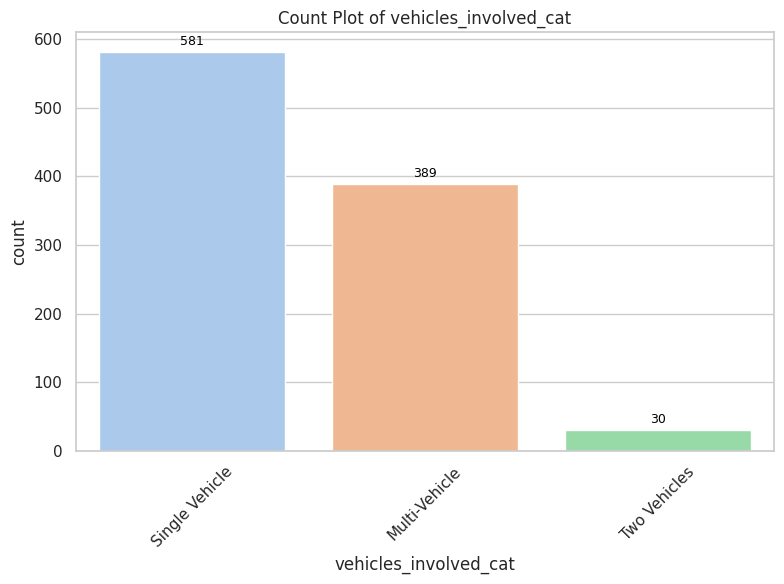

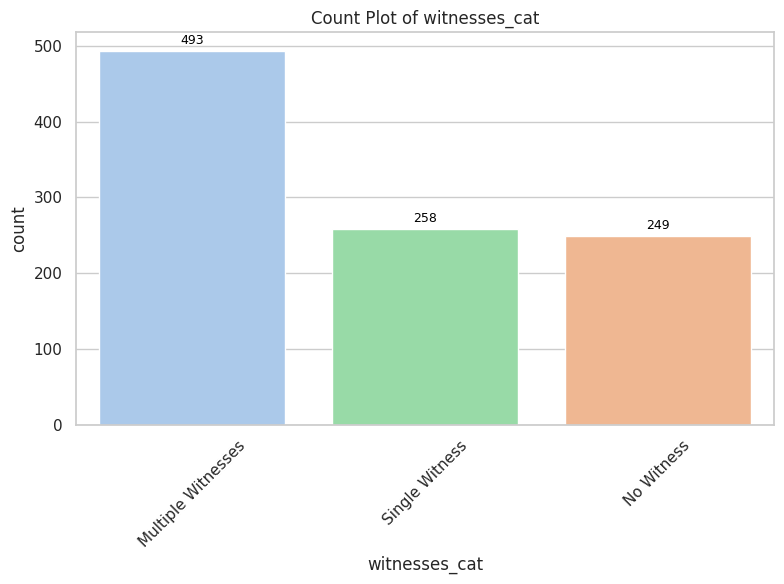

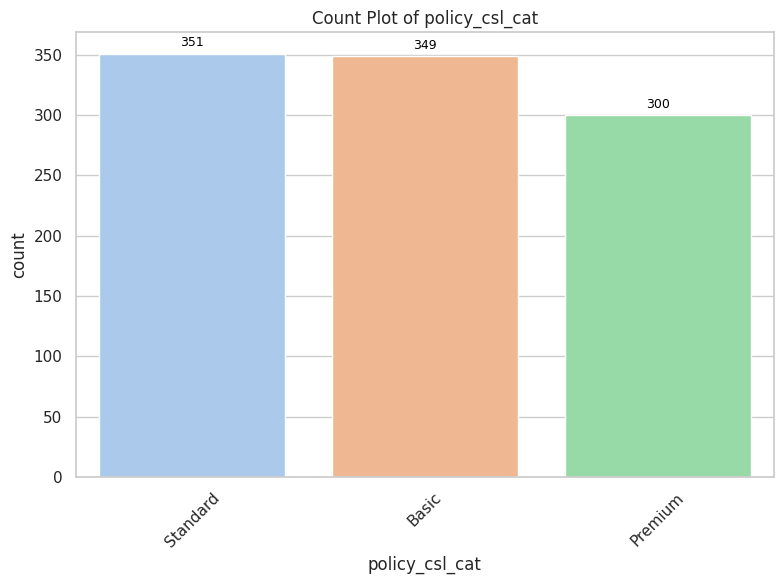

,Feature,Unique Values,Most Frequent,Most Frequent %,Missing
0,policy_state,3,OH,35.2,0
1,insured_sex,2,FEMALE,53.7,0
2,insured_education_level,7,JD,16.1,0
3,insured_occupation,14,machine-op-inspct,9.3,0
4,insured_hobbies,20,reading,6.4,0
5,insured_relationship,6,own-child,18.3,0
6,incident_type,4,Multi-vehicle Collision,41.9,0
7,collision_type,4,Rear Collision,29.2,178
8,incident_severity,4,Minor Damage,35.4,0
9,authorities_contacted,5,Police,29.2,91


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Overview: store summary results
cat_summary = []

for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(normalize=True, dropna=False) * 100
    n_unique = df[col].nunique(dropna=False)
    most_common = counts.index[0]
    most_common_pct = percents.iloc[0]

    cat_summary.append({
        "Feature": col,
        "Unique Values": n_unique,
        "Most Frequent": most_common,
        "Most Frequent %": round(most_common_pct, 2),
        "Missing": df[col].isna().sum()
    })

    # Plot
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=df, x=col, hue=col, order=counts.index[:10], palette="pastel", legend=False)

    # Add count labels
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3), textcoords='offset points')

    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Create a summary table
cat_summary_df = pd.DataFrame(cat_summary)
cat_summary_df

Feature Distribution Insights

| Feature             | Interpretation                                                                        |
| ------------------- | ------------------------------------------------------------------------------------- |
| `policy_state`      | 3 states, with **OH dominating (35.2%)** — consider one-hot or frequency encoding.    |
| `insured_sex`       | Balanced but slightly more **FEMALE (53.7%)** — low cardinality.                      |
| `incident_type`     | 4 types — **"Multi-vehicle Collision"** is dominant (41.9%).                          |
| `incident_severity` | Reasonably distributed, **"Minor Damage"** leads at 35.4%.                            |
| `fraud_reported`    | **Imbalanced target** — only \~24.7% fraud (N = 75.3%). Consider stratified sampling. |


Features with High Cardinality

| Feature              | Unique Values | Recommendation                                             |
| -------------------- | ------------- | ---------------------------------------------------------- |
| `incident_location`  | 1000          | Too granular — drop or encode using geohashing, zip/state. |
| `auto_model`         | 39            | Consider grouping rare models under "Other".               |
| `insured_occupation` | 14            | Can use frequency or target encoding.                      |
| `insured_hobbies`    | 20            | May need grouping — low signal-to-noise ratio.             |


Features With Missing Values

| Feature                   | Missing | Most Frequent          | Note                                                          |
| ------------------------- | ------- | ---------------------- | ------------------------------------------------------------- |
| `collision_type`          | 178     | Rear Collision (29.2%) | Might encode **"Unknown"** or use imputation.                 |
| `authorities_contacted`   | 91      | Police (29.2%)         | Can impute or set "Unknown". Might be informative for fraud.  |
| `property_damage`         | 360     | NaN (36%)              | Large proportion missing → create a missing indicator column. |
| `police_report_available` | 343     | NaN (34.3%)            | Same as above — strong fraud signal possible.                 |


Engineered Features Look Good

| Feature                 | Top Category           | Interpretation                                               |
| ----------------------- | ---------------------- | ------------------------------------------------------------ |
| `policy_deductable_cat` | Medium (35.1%)         | Deductibles successfully binned.                             |
| `umbrella_limit_cat`    | None (79.8%)           | Most users have **no extra umbrella coverage**.              |
| `bodily_injuries_cat`   | None (34%)             | Could be an important fraud flag.                            |
| `incident_hour_cat`     | Afternoon (27.1%)      | Possibly more traffic incidents during this time.            |
| `vehicles_involved_cat` | Single Vehicle (58.1%) | Could indicate **no other party involved** — fraud-prone?    |
| `witnesses_cat`         | Multiple (49.3%)       | Surprisingly high — investigate if witness data is inflated. |
| `policy_csl_cat`        | Standard (35.1%)       | Most users select mid-tier liability coverage.               |


# Categorical vs. Categorical

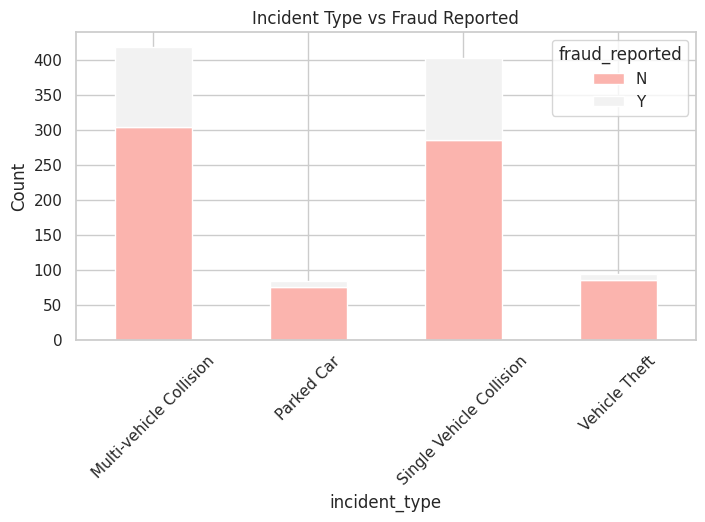

In [27]:
# Cross-tabulation
pd.crosstab(df['incident_type'], df['fraud_reported'], normalize='index') * 100

# Stacked bar chart
df.groupby(['incident_type', 'fraud_reported']).size().unstack().plot(
    kind='bar', stacked=True, colormap='Pastel1', figsize=(8,4))
plt.title('Incident Type vs Fraud Reported')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


# Numerical vs. Categorical

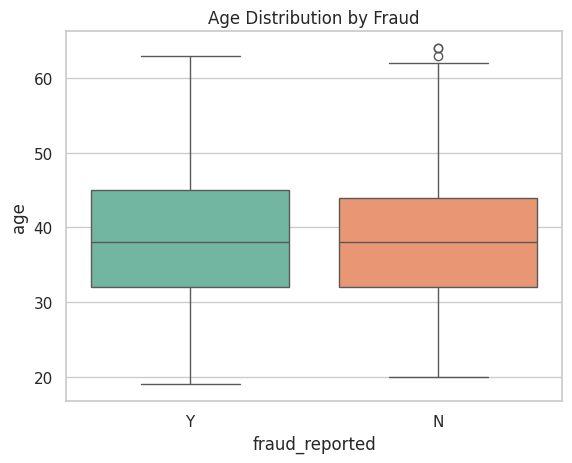

,count,mean,std,min,25%,50%,75%,max
fraud_reported,,,,,,,,
N,753.0,38.884462,8.973139,20.0,32.0,38.0,44.0,64.0
Y,247.0,39.141700,9.648295,19.0,32.0,38.0,45.0,63.0


In [29]:
# Boxplot
sns.boxplot(x='fraud_reported', y='age', data=df, hue='fraud_reported', palette='Set2', legend=False)

plt.title('Age Distribution by Fraud')
plt.show()

# Group stats
df.groupby('fraud_reported')['age'].describe()


# Numerical vs. Numerical

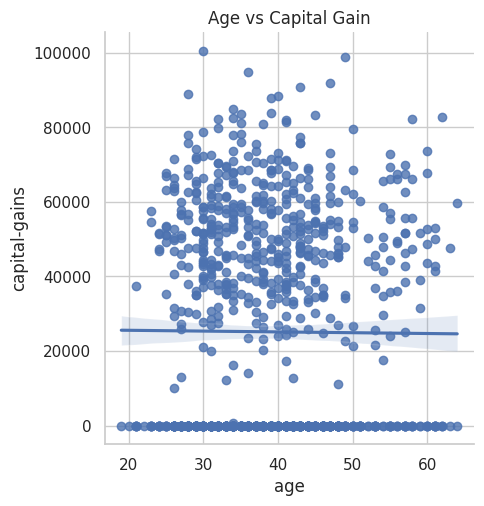

In [33]:
# Correlation
df[['age', 'capital-gains']].corr()

# Scatterplot with regression
sns.lmplot(x='age', y='capital-gains', data=df)
plt.title('Age vs Capital Gain')
plt.show()

# Chi-Square Test (Categorical vs. Categorical)

In [34]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['fraud_reported'], df['incident_type'])
chi2, p, dof, ex = chi2_contingency(table)
print(f"Chi2 Stat: {chi2:.2f}, p-value: {p:.4f}")

Chi2 Stat: 29.13, p-value: 0.0000


# ANOVA (Categorical vs. Numerical)

In [35]:
from scipy.stats import f_oneway

fraud_yes = df[df['fraud_reported'] == 'Y']['age']
fraud_no = df[df['fraud_reported'] == 'N']['age']

f_stat, p = f_oneway(fraud_yes, fraud_no)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p:.4f}")

ANOVA F-statistic: 0.15, p-value: 0.7013


# Correlation Heatmap (Numerical vs Numerical)

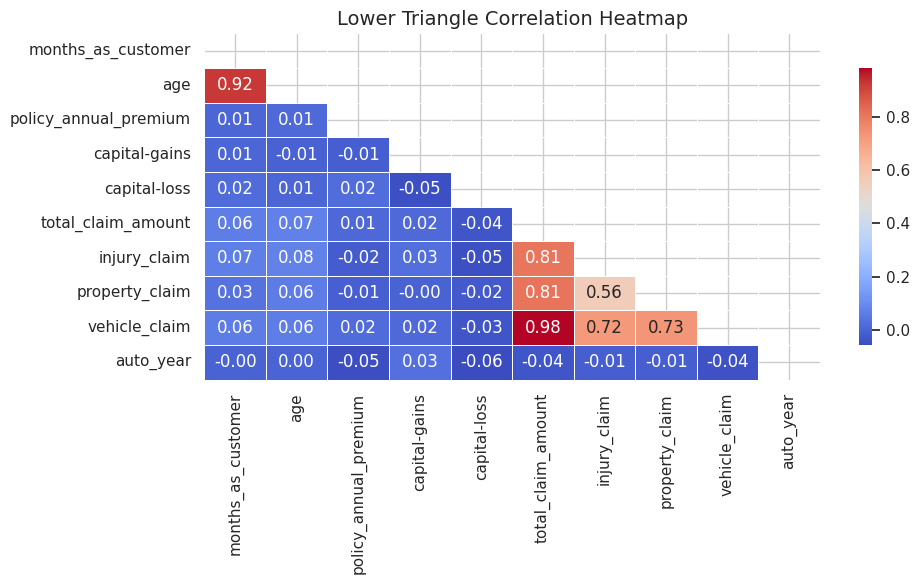

In [37]:
# Compute correlation matrix
corr = df.select_dtypes(include=np.number).corr()

# Generate mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            linewidths=0.5, 
            cbar_kws={"shrink": 0.8})

plt.title("Lower Triangle Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


| Feature A            | Feature B        | Key Insight (Example)                                                                    |
| -------------------- | ---------------- | ---------------------------------------------------------------------------------------- |
| `incident_type`      | `fraud_reported` | Single-vehicle incidents may show higher fraud — check proportion and Chi-square p-value |
| `age`                | `fraud_reported` | Fraud may be more common among certain age groups — compare means and boxplots           |
| `witnesses_cat`      | `fraud_reported` | Fraud more likely when there are **no witnesses** — strong red flag                      |
| `insured_occupation` | `fraud_reported` | Certain jobs may correlate with fraud — inspect occupation frequency and fraud share     |
| `umbrella_limit`     | `fraud_reported` | Higher policy limits may be more targeted for fraud — check group mean distributions     |


In [38]:
# Count missing values
missing_df = df.isnull().sum().to_frame("Missing Count")
missing_df["Missing %"] = (df.isnull().mean() * 100).round(2)
missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df

,Missing Count,Missing %
collision_type,178,17.8
authorities_contacted,91,9.1
property_damage,360,36.0
police_report_available,343,34.3


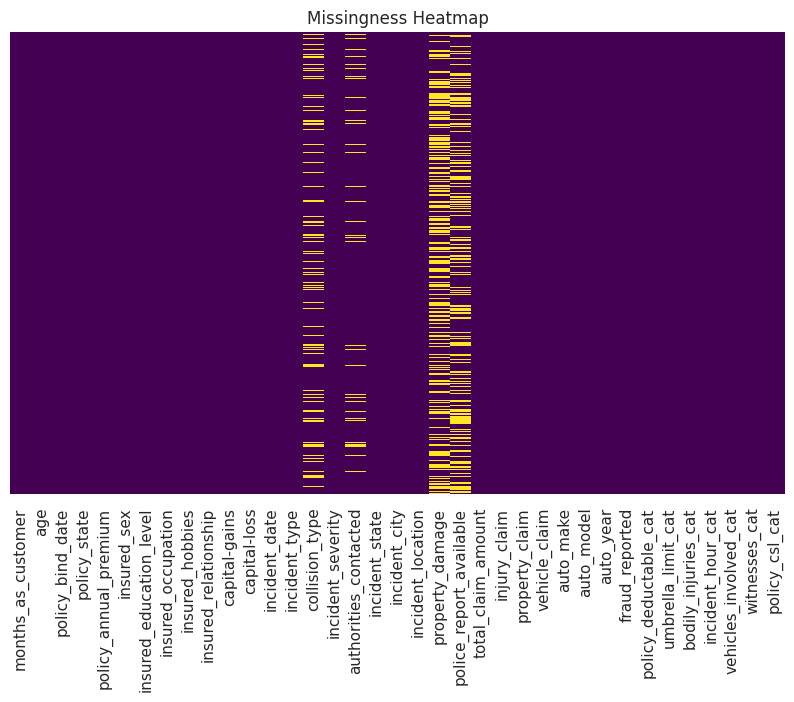

In [39]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missingness Heatmap")
plt.show()